In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report,roc_curve, roc_auc_score

df = pd.read_csv("Employee.csv")
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Company  140 non-null    object 
 1   Age      130 non-null    float64
 2   Salary   124 non-null    float64
 3   Place    134 non-null    object 
 4   Country  148 non-null    object 
 5   Gender   148 non-null    int64  
dtypes: float64(2), int64(1), object(3)
memory usage: 7.1+ KB


Explore the data, list down the unique values in each feature and find its length.

In [2]:
df_list = list(df.columns)
for i in df_list:
  print(f"************* {i} ***********************")
  print(df[i].value_counts())

************* Company ***********************
Company
TCS                          53
Infosys                      45
CTS                          36
Tata Consultancy Services     2
Congnizant                    2
Infosys Pvt Lmt               2
Name: count, dtype: int64
************* Age ***********************
Age
22.0    16
33.0    13
44.0    10
34.0     8
21.0     8
23.0     8
32.0     7
35.0     6
0.0      6
41.0     5
45.0     4
24.0     4
43.0     4
31.0     3
20.0     3
25.0     3
36.0     3
40.0     3
50.0     2
37.0     2
30.0     2
26.0     2
46.0     2
18.0     1
19.0     1
38.0     1
51.0     1
17.0     1
54.0     1
Name: count, dtype: int64
************* Salary ***********************
Salary
3000.0    9
5000.0    6
5034.0    5
4034.0    5
8202.0    5
1089.0    4
2300.0    4
5835.0    4
8787.0    4
8943.0    4
9284.0    4
8345.0    4
2034.0    4
4824.0    4
3045.0    4
1234.0    4
2934.0    4
9024.0    4
7084.0    4
3184.0    4
6000.0    3
9000.0    3
7000.0    3
8000.0   

Perform the statistical analysis and renaming of the columns.

In [3]:
#renaming of the columns.
df.rename(columns={'Company': 'Organisation'}, inplace=True)
print(df)

    Organisation   Age  Salary     Place Country  Gender
0            TCS  20.0     NaN   Chennai   India       0
1        Infosys  30.0     NaN    Mumbai   India       0
2            TCS  35.0  2300.0  Calcutta   India       0
3        Infosys  40.0  3000.0     Delhi   India       0
4            TCS  23.0  4000.0    Mumbai   India       0
..           ...   ...     ...       ...     ...     ...
143          TCS  33.0  9024.0  Calcutta   India       1
144      Infosys  22.0  8787.0  Calcutta   India       1
145      Infosys  44.0  4034.0     Delhi   India       1
146          TCS  33.0  5034.0    Mumbai   India       1
147      Infosys  22.0  8202.0    Cochin   India       0

[148 rows x 6 columns]


In [4]:
#Perform the statistical analysis , mean ,medan , mode
print(" Age mean :",df['Age'].mean())
print(" Salary  Mode :",df['Salary'].mode())
print(" Salary Median :",df['Salary'].median())

 Age mean : 30.484615384615385
 Salary  Mode : 0    3000.0
Name: Salary, dtype: float64
 Salary Median : 5000.0


Find the missing and inappropriate values, treat them appropriately.

In [5]:
#Find the missing and inappropriate values
df.isnull().sum()

,0
Organisation,8
Age,18
Salary,24
Place,14
Country,0
Gender,0


In [7]:
# treat them appropriately.

df["Organisation"] = df["Organisation"].ffill().bfill()
df['Place']=df['Place'].fillna(df['Place'].mode()[0])
#df['Age']=df['Age'].fillna(df['Age'].mean().round(0))
df['Salary']=df['Salary'].fillna(df['Salary'].mean().round(0))
df.isnull().sum()
print(df.iloc[30:40])

   Organisation   Age  Salary      Place Country  Gender
30          CTS  46.0  7654.0    Chennai   India       0
31          CTS  20.0  2934.0     Mumbai   India       0
32      Infosys  45.0  4034.0   Calcutta   India       0
33          TCS  36.0  5034.0     Mumbai   India       0
34      Infosys  26.0  8202.0     Mumbai   India       0
35          TCS  35.0  9024.0     Mumbai   India       1
36          TCS  32.0  5312.0      Noida   India       0
37          TCS  35.0  5312.0  Hyderabad   India       0
38          TCS  34.0  2300.0   Calcutta   India       0
39      Infosys  41.0  3000.0     Mumbai   India       0


In [11]:
#Remove all duplicate rows.
print(df[df.duplicated()])
df = df.drop_duplicates().reset_index(drop=True)
print("Duplicate rows are removed",df[df.duplicated()])

Empty DataFrame
Columns: [Organisation, Age, Salary, Place, Country, Gender]
Index: []
Duplicate rows are removed Empty DataFrame
Columns: [Organisation, Age, Salary, Place, Country, Gender]
Index: []


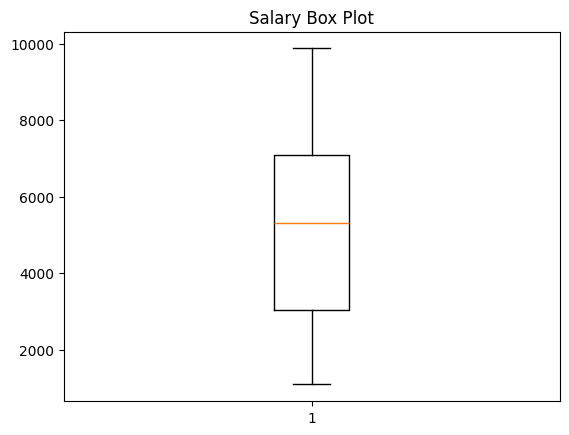

In [12]:
#Find the outliers.
plt.boxplot(df['Salary'])
plt.title('Salary Box Plot')
plt.show()

<Axes: ylabel='Salary'>

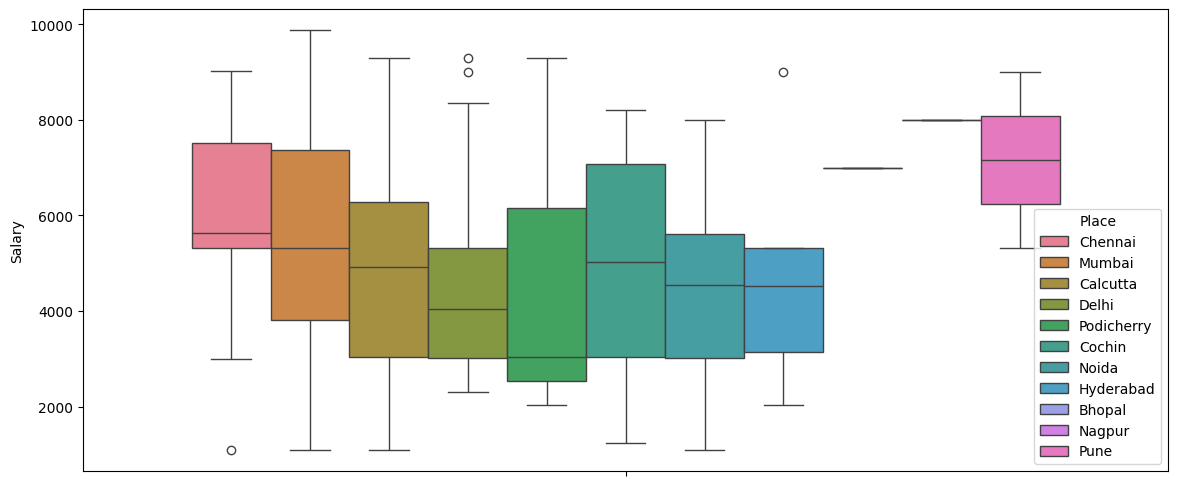

In [29]:
plt.figure(figsize=(14, 6))
sns.boxplot(y="Salary",hue="Place", data=df)


Replace the value 0 in age as NaN Treat the null values in all columns using any
measures(removing/ replace the values with mean/median/mode) .

In [13]:
print(df[df['Age']<1])  #find 0s

    Organisation  Age  Salary       Place Country  Gender
87       Infosys  0.0  3030.0    Calcutta   India       0
91           TCS  0.0  3045.0       Delhi   India       0
100          CTS  0.0  2034.0  Podicherry   India       0
106          TCS  0.0  9024.0     Chennai   India       1
110      Infosys  0.0  3234.0      Mumbai   India       0
120          CTS  0.0  1234.0    Calcutta   India       0


In [14]:
df['Age'] = df['Age'].replace(0, np.nan) # replase 0's with Na, check 0s again
print(df[df['Age']<1])

Empty DataFrame
Columns: [Organisation, Age, Salary, Place, Country, Gender]
Index: []


In [15]:
df['Age']=df['Age'].fillna(df['Age'].mean().round(0))  #replase na with mean

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Organisation  144 non-null    object 
 1   Age           144 non-null    float64
 2   Salary        144 non-null    float64
 3   Place         144 non-null    object 
 4   Country       144 non-null    object 
 5   Gender        144 non-null    int64  
dtypes: float64(2), int64(1), object(3)
memory usage: 6.9+ KB


In [17]:
print(df[df['Age'].isna()])  # check na

Empty DataFrame
Columns: [Organisation, Age, Salary, Place, Country, Gender]
Index: []


 Filter the data with age >40 and salary<5000 Plot the chart with age and salaryCount the number of people from each place and represent it visually

In [53]:
Ag_Sal_Filter =  df[(df["Age"]>40) & (df["Salary"]<5000)].reset_index(drop=True)
Ag_Sal_Filter

,Organisation,Age,Salary,Place,Country,Gender
0,Infosys,50.0,3184.0,Delhi,India,0
1,Infosys,45.0,4034.0,Calcutta,India,0
2,Infosys,41.0,3000.0,Mumbai,India,0
3,Infosys,41.0,3000.0,Chennai,India,0
4,Infosys,51.0,3184.0,Hyderabad,India,0
5,Infosys,43.0,4034.0,Mumbai,India,0
6,Infosys,44.0,3000.0,Cochin,India,0
7,Infosys,41.0,3000.0,Delhi,India,0
8,Infosys,54.0,3184.0,Mumbai,India,0
9,Infosys,44.0,4034.0,Delhi,India,0


Place
Delhi        4
Mumbai       4
Calcutta     2
Hyderabad    2
Cochin       2
Chennai      1
Name: count, dtype: int64


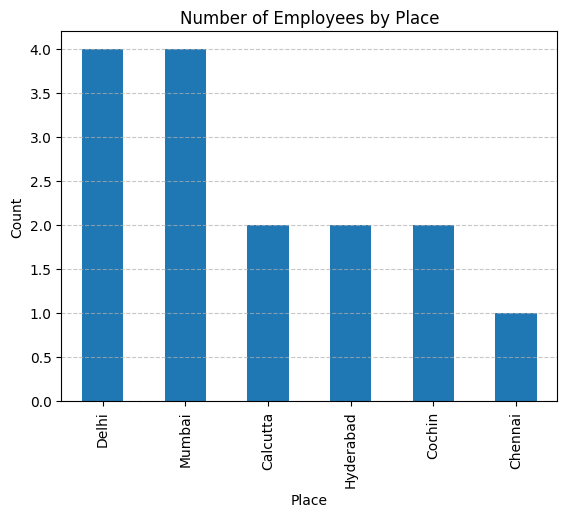

In [54]:
place_count = Ag_Sal_Filter["Place"].value_counts()
print(place_count)

place_count.plot(kind="bar")
plt.title("Number of Employees by Place")
plt.xlabel("Place")
plt.ylabel("Count")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Convert categorical variables into numerical representations using techniques
such as one-hot encoding, label encoding, making them suitable for analysis by
machine learning algorithms.

In [55]:
Ag_Sal_Filter

,Organisation,Age,Salary,Place,Country,Gender
0,Infosys,50.0,3184.0,Delhi,India,0
1,Infosys,45.0,4034.0,Calcutta,India,0
2,Infosys,41.0,3000.0,Mumbai,India,0
3,Infosys,41.0,3000.0,Chennai,India,0
4,Infosys,51.0,3184.0,Hyderabad,India,0
5,Infosys,43.0,4034.0,Mumbai,India,0
6,Infosys,44.0,3000.0,Cochin,India,0
7,Infosys,41.0,3000.0,Delhi,India,0
8,Infosys,54.0,3184.0,Mumbai,India,0
9,Infosys,44.0,4034.0,Delhi,India,0


In [66]:
#One-Hot Encoding "Organisation"
Ag_Sal_Filter_encoded = pd.get_dummies(Ag_Sal_Filter, columns=['Organisation'], dtype=int, drop_first=True)
Ag_Sal_Filter_encoded

,Age,Salary,Place,Country,Gender,Organisation_Infosys
0,50.0,3184.0,Delhi,India,0,1
1,45.0,4034.0,Calcutta,India,0,1
2,41.0,3000.0,Mumbai,India,0,1
3,41.0,3000.0,Chennai,India,0,1
4,51.0,3184.0,Hyderabad,India,0,1
5,43.0,4034.0,Mumbai,India,0,1
6,44.0,3000.0,Cochin,India,0,1
7,41.0,3000.0,Delhi,India,0,1
8,54.0,3184.0,Mumbai,India,0,1
9,44.0,4034.0,Delhi,India,0,1


In [68]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
Ag_Sal_Filter_encoded["Place"] = le.fit_transform(Ag_Sal_Filter_encoded["Place"])
Ag_Sal_Filter_encoded.drop('Country', axis=1, inplace=True)
Ag_Sal_Filter_encoded


,Age,Salary,Place,Gender,Organisation_Infosys
0,50.0,3184.0,3,0,1
1,45.0,4034.0,0,0,1
2,41.0,3000.0,5,0,1
3,41.0,3000.0,1,0,1
4,51.0,3184.0,4,0,1
5,43.0,4034.0,5,0,1
6,44.0,3000.0,2,0,1
7,41.0,3000.0,3,0,1
8,54.0,3184.0,5,0,1
9,44.0,4034.0,3,0,1


After the process of encoding, perform the scaling of the features using
standardscaler and minmaxscaler.

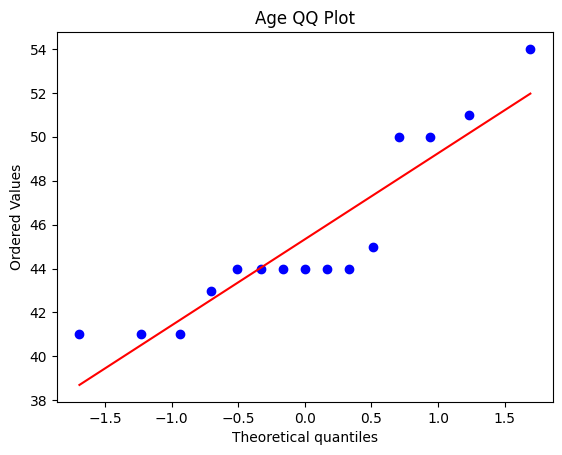

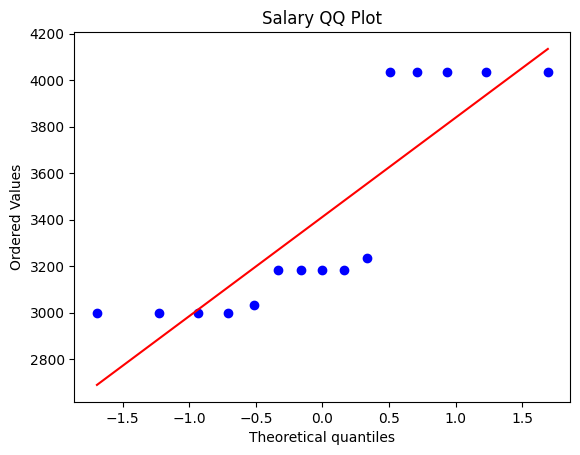

In [81]:
from scipy import stats

stats.probplot(Ag_Sal_Filter_encoded['Age'], dist='norm', plot=plt)
plt.title("Age QQ Plot")
plt.show()
stats.probplot(Ag_Sal_Filter_encoded['Salary'], dist='norm', plot=plt)
plt.title("Salary QQ Plot")
plt.show()

In [87]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
scaler = StandardScaler()
mm_scaler = MinMaxScaler()
Ag_Sal_Filter_encoded[['Age', 'Salary']] = scaler.fit_transform(Ag_Sal_Filter_encoded[['Age', 'Salary']])
print("StandardScaler\n",Ag_Sal_Filter_encoded)
Ag_Sal_Filter_encoded[['Age', 'Salary']] = mm_scaler.fit_transform(Ag_Sal_Filter_encoded[['Age', 'Salary']])
print("**********************************************")
print("MinMaxScaler\n",Ag_Sal_Filter_encoded)


StandardScaler
          Age    Salary  Place  Gender  Organisation_Infosys
0   1.209416 -0.509064      3       0                     1
1  -0.086387  1.392655      0       0                     1
2  -1.123029 -0.920730      5       0                     1
3  -1.123029 -0.920730      1       0                     1
4   1.468576 -0.509064      4       0                     1
5  -0.604708  1.392655      5       0                     1
6  -0.345547 -0.920730      2       0                     1
7  -1.123029 -0.920730      3       0                     1
8   2.246058 -0.509064      5       0                     1
9  -0.345547  1.392655      3       0                     1
10 -0.345547 -0.397198      5       0                     1
11  1.209416 -0.509064      0       0                     1
12 -0.345547 -0.846899      2       0                     0
13 -0.345547  1.392655      4       0                     1
14 -0.345547  1.392655      3       1                     1
************************